In [143]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

### Problem 2

In [144]:
#constants
gain = 2
readnoise = 12 #electrons
sky_intensity = 1.3
radius = 5 #pixels
m_ref = 21
flux_ref_adu = 1
sat_limit_adu = 350000
exp_time = 300

area = np.pi * radius**2
sky_count_sec_ap = sky_intensity * area
total_sky_adu = sky_count_sec_ap * exp_time

magnitudes = np.linspace(10,25,5000)

In [145]:
#solving for star flux in ADU/sec
star_rate_adu = flux_ref_adu*10**(0.4*(m_ref - magnitudes))

#total star count in exp time
star_total_adu = star_rate_adu * exp_time

#total count
total_count = star_total_adu + total_sky_adu


<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bhoom\AppData\Local\Temp\ipykernel_31384\2490418395.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(Total Counts)$ [ADU]')


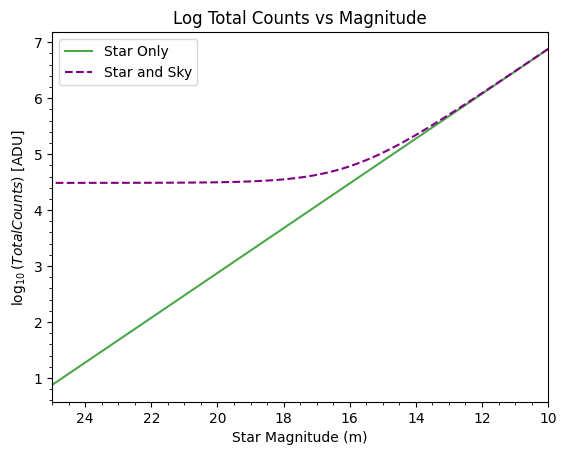

In [ ]:
#plot total v mag
plt.plot(magnitudes, np.log10(star_total_adu), label='Star Only', color='green', alpha = 0.7)
plt.plot(magnitudes, np.log10(total_count), label='Star and Sky', color='purple', linestyle='--')
plt.xlabel('Star Magnitude (m)')
plt.ylabel('$\log_{10}(Total Counts)$ [ADU]')
plt.title('Log Total Counts vs Magnitude')
plt.xlim(25,10)
plt.minorticks_on()
plt.legend()

In [147]:
#all into electron calculations
star_e = star_total_adu * gain
sky_e = total_sky_adu * gain

In [148]:
#CCD SNR
noise = np.sqrt(star_e + sky_e + area*(readnoise**2))
snr = star_e / noise

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bhoom\AppData\Local\Temp\ipykernel_31384\2208725790.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(S/N)$')


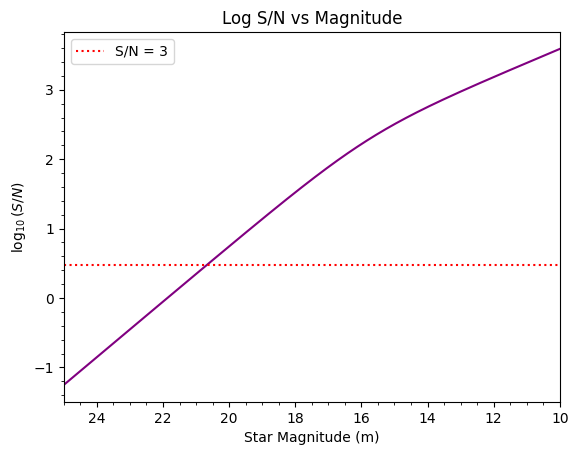

In [149]:
plt.plot(magnitudes, np.log10(snr), color='purple')
plt.axhline(np.log10(3.0), color='red', linestyle=':', label='S/N = 3')
plt.xlabel('Star Magnitude (m)')
plt.ylabel('$\log_{10}(S/N)$')
plt.title('Log S/N vs Magnitude')
plt.xlim(25,10)
plt.legend()
plt.minorticks_on()

In [150]:
# Saturation mag
m_sat = 21 - 2.5*np.log10(sat_limit_adu/exp_time)
print("Saturation magnitude is approximately", round(m_sat, 2))

# Limiting mag
idx = np.argmin(np.abs(snr - 3))
print("Limiting magnitude (S/N=3) is approximately", round(magnitudes[idx], 2))

Saturation magnitude is approximately 13.33
Limiting magnitude (S/N=3) is approximately 20.67


### Problem 3

C:\Users\bhoom\AppData\Local\Temp\ipykernel_31384\2078522877.py:18: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(t), np.log10(snr_t))


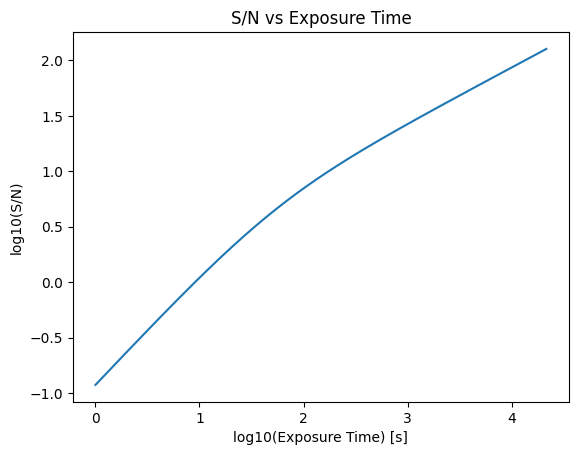

In [ ]:
m = 18.99
star_rate = 10**(-0.4*(m-21))

t = np.linspace(0, 21600, 21600)

star_total_t = star_rate * t
sky_total_t = sky_intensity * area * t

star_e_t = star_total_t * gain
sky_e_t = sky_total_t * gain

noise_t = np.sqrt(star_e_t + sky_e_t + area*(readnoise**2))
snr_t = star_e_t / noise_t


plt.figure()
plt.plot(np.log10(t), np.log10(snr_t))
plt.xlabel("log10(Exposure Time) [s]")
plt.ylabel("log10(S/N)")
plt.title("S/N vs Exposure Time")
plt.show()

In [177]:
differences = np.abs(snr_t - 30)
min_diff_value = np.min(differences)
indices = np.where(differences == min_diff_value)[0]
idx = indices[0]
t_required = t[idx]

print("Exposure time for S/N=30 is approximately", round(t_required/60, 1), "minutes")

Exposure time for S/N=30 is approximately 20.9 minutes


### Problem 4

In [153]:
imname='M84.fits'
imhdr=fits.getheader(imname)
imdata=fits.getdata(imname)
X, Y = np.meshgrid( np.arange(1,imhdr['NAXIS1']+1), np.arange(1,imhdr['NAXIS2']+1) )

In [154]:
#constants from region
npix = 963
mean = 2.05538
median = 1.9425
stddev = 4.48441

sky_error = stddev / np.sqrt(npix)

In [155]:
#constants determined by me
x_center = 713.5
y_center = 739.33

In [156]:
Xc, Yc = x_center, y_center
R = np.sqrt( (X-Xc)**2 + (Y-Yc)**2 )
R=R.flatten()
pixvals=imdata.flatten()

In [157]:
corrected_pixval = pixvals - median

In [158]:
pixscale = 1.45  # arcsec/pixel
zeropoint = 28.60
pixel_area = pixscale**2  # arcsec^2

In [ ]:
bin_edges = np.arange(0,500,10)
print(bin_edges)

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350
 360 370 380 390 400 410 420 430 440 450 460 470 480 490]


In [160]:
stat='mean'
bin_yavg, bin_edges, bin_num = binned_statistic(R,corrected_pixval,statistic=stat,bins=bin_edges)
bin_centers=0.5*(bin_edges[1:]+bin_edges[:-1])
mu_mean = -2.5 * np.log10(bin_yavg / pixel_area) + zeropoint

In [161]:
stat='median'
bin_ymed, bin_edges, bin_num = binned_statistic(R,corrected_pixval,statistic=stat,bins=bin_edges)
bin_centers=0.5*(bin_edges[1:]+bin_edges[:-1])
mu_median = -2.5 * np.log10(bin_ymed / pixel_area) + zeropoint

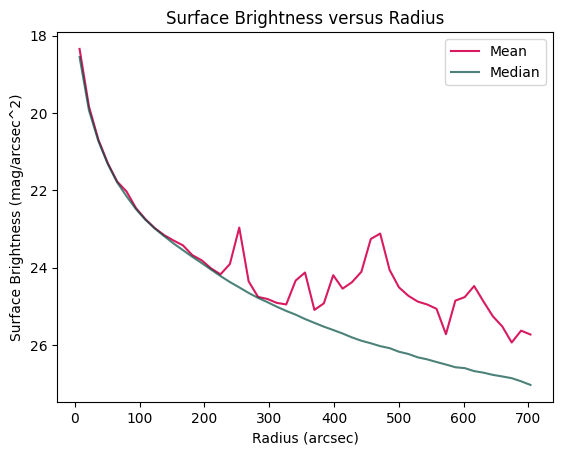

In [175]:
radius_arcsec = bin_centers * pixscale
plt.figure()
plt.plot(radius_arcsec, mu_mean, label='Mean', color = "#D81B60")
plt.plot(radius_arcsec, mu_median, label='Median', color = "#004D40", alpha = 0.7)
plt.gca().invert_yaxis()
plt.xlabel("Radius (arcsec)")
plt.ylabel("Surface Brightness (mag/arcsec^2)")
plt.title("Surface Brightness versus Radius")
plt.legend()

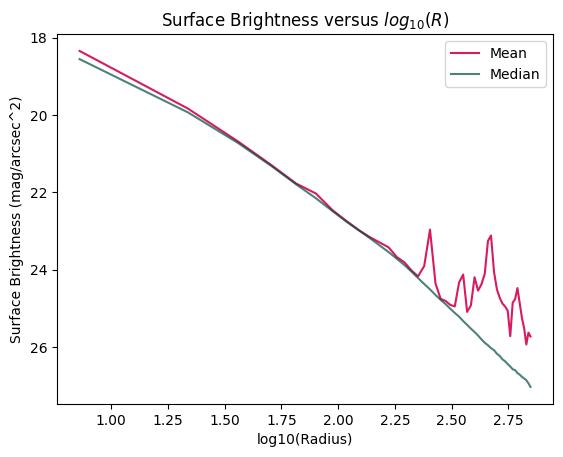

In [173]:
plt.plot(np.log10(radius_arcsec), mu_mean, label='Mean', color = "#D81B60")
plt.plot(np.log10(radius_arcsec), mu_median, label='Median', color = "#004D40", alpha = 0.7)
plt.gca().invert_yaxis()
plt.xlabel("log10(Radius)")
plt.ylabel("Surface Brightness (mag/arcsec^2)")
plt.title("Surface Brightness versus $log_{10}(R)$")
plt.legend()

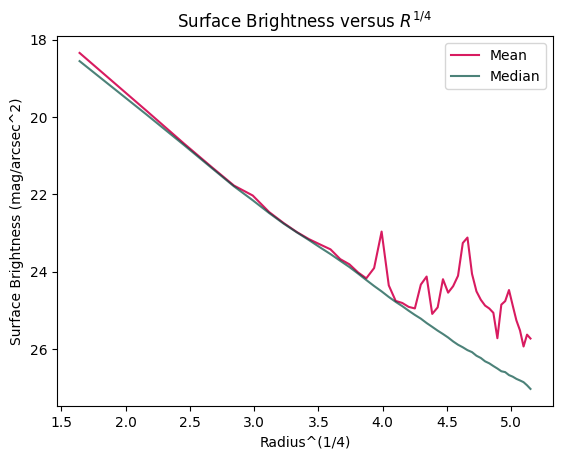

In [174]:
plt.plot(radius_arcsec**0.25, mu_mean, label='Mean', color = "#D81B60")
plt.plot(radius_arcsec**0.25, mu_median, label='Median', color = "#004D40", alpha = 0.7)
plt.gca().invert_yaxis()
plt.xlabel("Radius^(1/4)")
plt.ylabel("Surface Brightness (mag/arcsec^2)")
plt.title("Surface Brightness versus $R^{1/4}$")
plt.legend()

In [182]:
cumulative_counts = []
running_total = 0

for i in range(len(bin_ymed)):
    
    r_in = bin_edges[i]
    r_out = bin_edges[i+1]
    
    annulus_area = np.pi * (r_out**2 - r_in**2)
    counts_annulus = bin_ymed[i] * annulus_area
    
    running_total += counts_annulus
    cumulative_counts.append(running_total)

cumulative_counts = np.array(cumulative_counts)

print("Total counts =", running_total)


Total counts = 61394444.24724457


In [183]:
m_total = -2.5*np.log10(running_total) + 28.60
print("Total V magnitude =", m_total)

Total V magnitude = 9.129677318968465


In [184]:
half_light_value = running_total / 2

index = np.where(cumulative_counts >= half_light_value)[0][0]

r_half_pixels = 0.5*(bin_edges[index] + bin_edges[index+1])

r_half_arcsec = r_half_pixels * pixscale

print("Half-light radius (pixels) =", r_half_pixels)
print("Half-light radius (arcsec) =", r_half_arcsec)


Half-light radius (pixels) = 75.0
Half-light radius (arcsec) = 108.75
